# E-commerce Sales Analysis

## Objective
Analyze sales data to identify trends, compare product categories, and generate business insights using Python and Matplotlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load th dataset

In [2]:
df = pd.read_csv(r"C:\Users\hande\Downloads\sales_data.csv")
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


# Clean the Data

In [3]:
df.drop_duplicates(inplace=True)

df["Date"] = pd.to_datetime(df["Date"])

# Explore the Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         100 non-null    datetime64[ns]
 1   Product      100 non-null    object        
 2   Quantity     100 non-null    int64         
 3   Price        100 non-null    int64         
 4   Customer_ID  100 non-null    object        
 5   Region       100 non-null    object        
 6   Total_Sales  100 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 5.6+ KB


In [5]:
df.describe()

,Date,Quantity,Price,Total_Sales
count,100,100.000000,100.000000,100.000000
mean,2024-02-19 12:00:00,4.780000,25808.510000,123650.480000
min,2024-01-01 00:00:00,1.000000,1308.000000,6540.000000
25%,2024-01-25 18:00:00,2.750000,14965.250000,39517.500000
50%,2024-02-19 12:00:00,5.000000,24192.000000,97955.500000
75%,2024-03-15 06:00:00,7.000000,38682.250000,175792.500000
max,2024-04-09 00:00:00,9.000000,49930.000000,373932.000000
std,NaN,2.588163,13917.630242,100161.085275


In [6]:
df.isnull().sum()

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

# Data Analysis

In [7]:
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [8]:
print("Total Sales:", df["Total_Sales"].sum())



Total Sales: 12365048


In [9]:
print("Average Sales:", df["Total_Sales"].mean())

Average Sales: 123650.48


In [10]:
print("Maximum Sale:", df["Total_Sales"].max())

Maximum Sale: 373932


# Product-wise Sales

In [11]:
product_sales = df.groupby("Product")["Total_Sales"].sum()

print(product_sales)

Product
Headphones    1384033
Laptop        3889210
Monitor       1348071
Phone         2859394
Tablet        2884340
Name: Total_Sales, dtype: int64


# 📊 Bar Chart

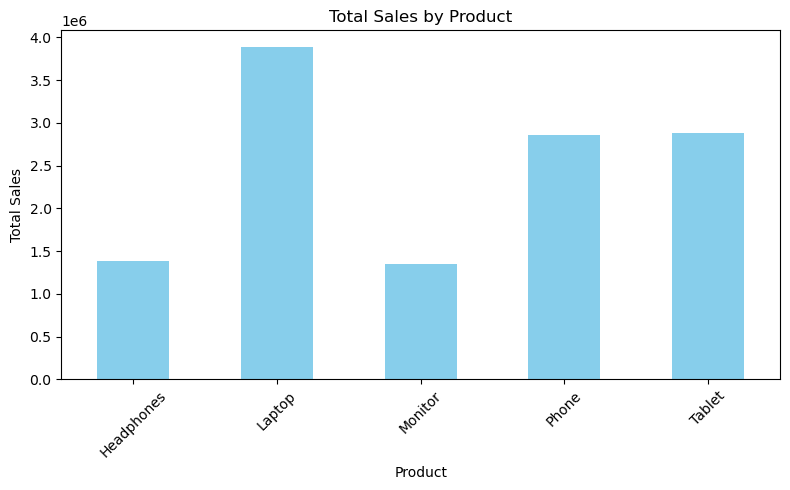

In [12]:
import matplotlib.pyplot as plt

product_sales.plot(kind="bar", figsize=(8,5), color="skyblue")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# 📈 Line Chart (Sales Over Time)

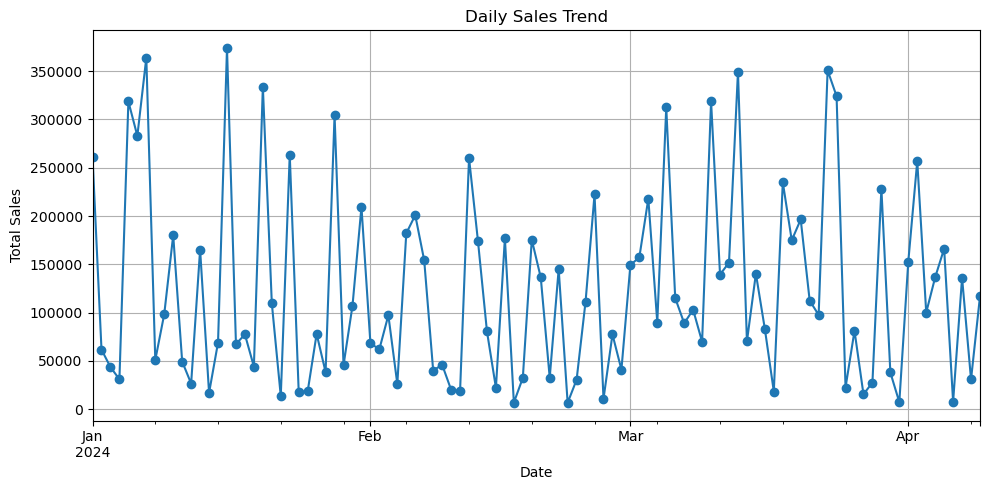

In [13]:
df["Date"] = pd.to_datetime(df["Date"])

daily_sales = df.groupby("Date")["Total_Sales"].sum()

daily_sales.plot(figsize=(10,5), marker="o")

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)

plt.tight_layout()
plt.show()

# Pie Chart

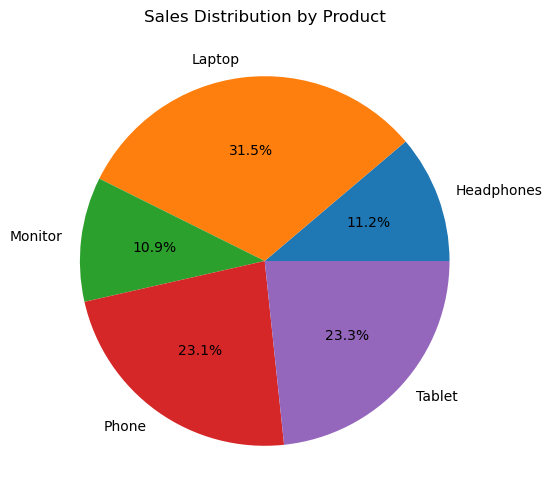

In [14]:
product_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Sales Distribution by Product")
plt.ylabel("")

plt.show()

# Total Quantity Sold

In [15]:
print(df["Quantity"].sum())

478


# Most Sold Product (by Quantity)

In [16]:
print(df.groupby("Product")["Quantity"].sum().sort_values(ascending=False))

Product
Laptop        136
Tablet        127
Phone         101
Monitor        66
Headphones     48
Name: Quantity, dtype: int64


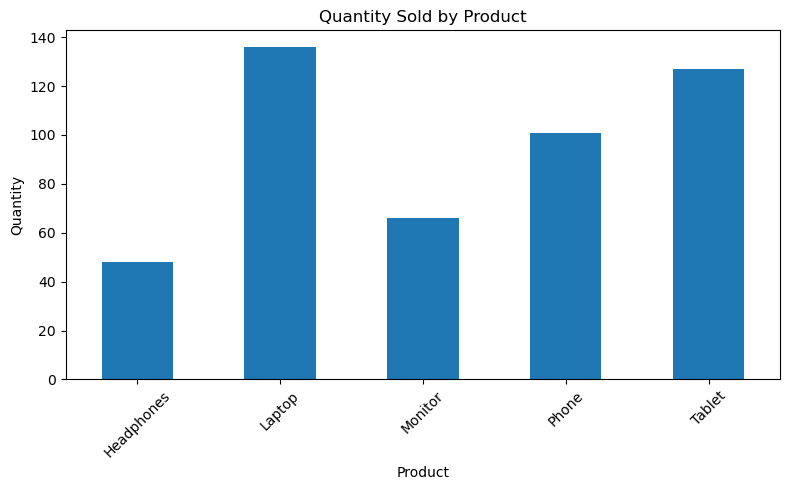

In [20]:
quantity = df.groupby("Product")["Quantity"].sum()

quantity.plot(kind="bar", figsize=(8,5))

plt.title("Quantity Sold by Product")

plt.xlabel("Product")

plt.ylabel("Quantity")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Sales by Region

In [21]:
region_sales = df.groupby("Region")["Total_Sales"].sum()
print(region_sales)

Region
East     2519639
North    3983635
South    3737852
West     2123922
Name: Total_Sales, dtype: int64


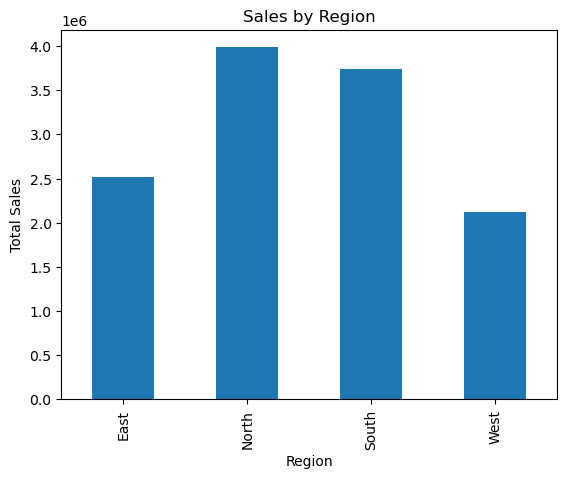

In [22]:
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

# Top 5 Customers by Sales

In [23]:
top_customers = df.groupby("Customer_ID")["Total_Sales"].sum().sort_values(ascending=False).head(5)

print(top_customers)

Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
Name: Total_Sales, dtype: int64
